In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load data
df = pd.read_csv('../data/processed/dengue_weather_monthly.csv')
df['month'] = pd.to_datetime(df['month'])

print("Data Loaded")
print(f"Rows: {len(df)} | Columns: {df.shape[1]}")
print(f"Period: {df['month'].min().date()} to {df['month'].max().date()}\n")
print(df.head())

Data Loaded
Rows: 132 | Columns: 7
Period: 2012-01-01 to 2022-12-01

       month  cases  rainfall  temperature  year  month_num  quarter
0 2012-01-01    338     106.1         24.3  2012          1        1
1 2012-02-01    258      83.6         24.8  2012          2        1
2 2012-03-01    231     313.4         24.4  2012          3        1
3 2012-04-01    363     260.6         24.8  2012          4        2
4 2012-05-01    338     292.0         24.8  2012          5        2


In [6]:
print("SUMMARY STATISTICS")
print("="*50)
print(df[['cases', 'rainfall', 'temperature']].describe())

SUMMARY STATISTICS
             cases    rainfall  temperature
count   132.000000  132.000000   132.000000
mean   1244.613636  164.350000    25.376515
std    1290.526963  101.179661     0.683375
min     136.000000    0.200000    23.800000
25%     347.750000   89.600000    24.800000
50%     947.000000  144.800000    25.350000
75%    1529.750000  216.700000    25.900000
max    6566.000000  692.800000    27.100000


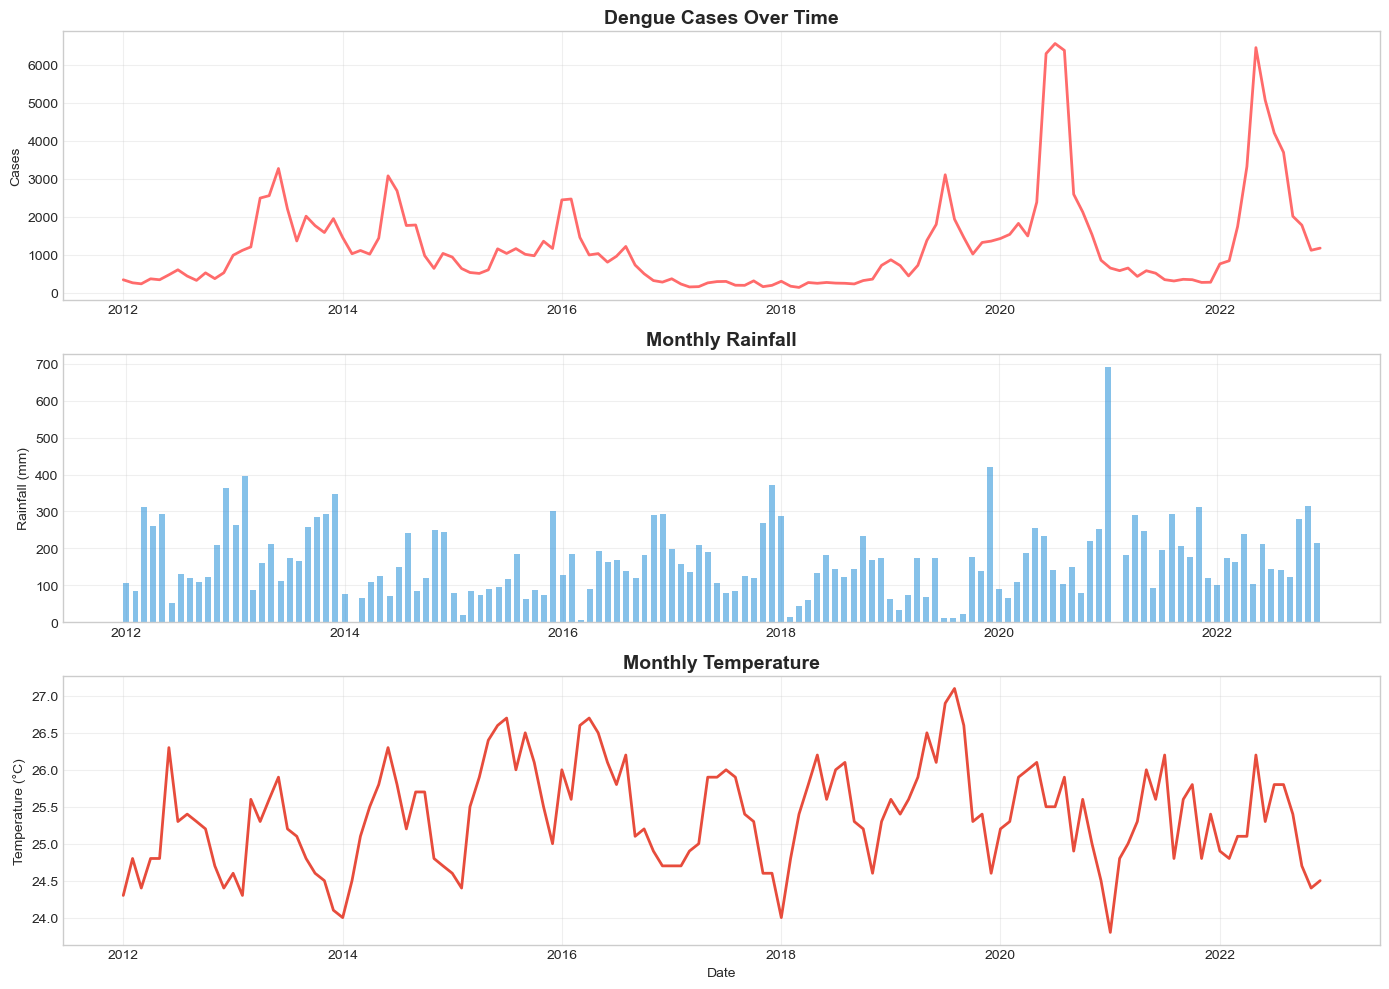

✅ Saved: images/01_time_series.png


In [7]:
# Simple 3-panel overview
fig, axes = plt.subplots(3, 1, figsize=(14, 10))

# Panel 1: Time series
axes[0].plot(df['month'], df['cases'], linewidth=2, color='#FF6B6B')
axes[0].set_title('Dengue Cases Over Time', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Cases')
axes[0].grid(alpha=0.3)

# Panel 2: Rainfall
axes[1].bar(df['month'], df['rainfall'], alpha=0.6, color='#3498db', width=20)
axes[1].set_title('Monthly Rainfall', fontsize=14, fontweight='bold')
axes[1].set_ylabel('Rainfall (mm)')
axes[1].grid(alpha=0.3)

# Panel 3: Temperature
axes[2].plot(df['month'], df['temperature'], linewidth=2, color='#e74c3c')
axes[2].set_title('Monthly Temperature', fontsize=14, fontweight='bold')
axes[2].set_ylabel('Temperature (°C)')
axes[2].set_xlabel('Date')
axes[2].grid(alpha=0.3)

plt.tight_layout()
import os
os.makedirs('../images', exist_ok=True)
plt.savefig('../images/01_time_series.png', dpi=300, bbox_inches='tight')
plt.show()

print("✅ Saved: images/01_time_series.png")

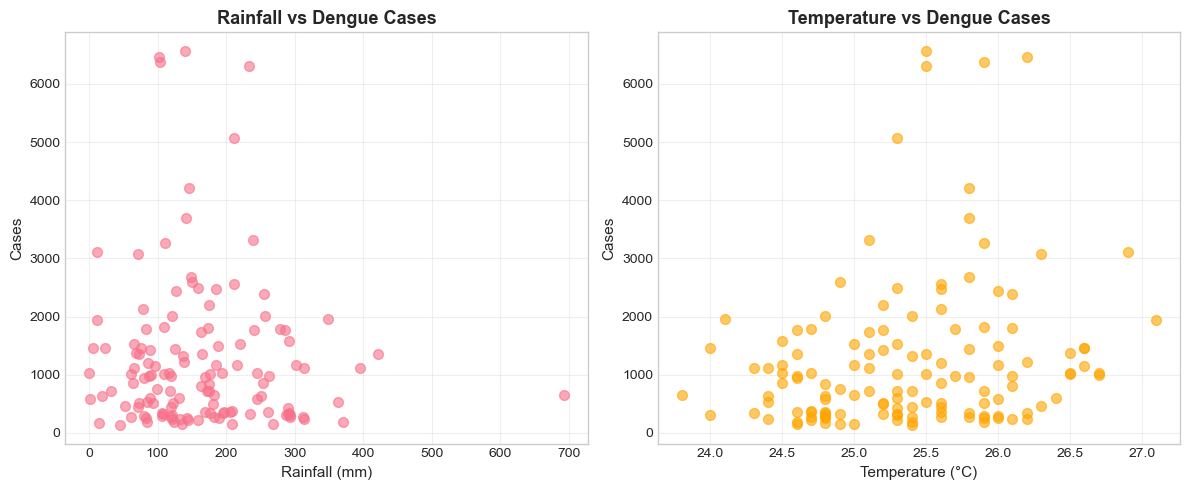

✅ Saved: images/02_relationships.png


In [8]:
# Simple scatter plots
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Rainfall vs Cases
axes[0].scatter(df['rainfall'], df['cases'], alpha=0.6, s=50)
axes[0].set_xlabel('Rainfall (mm)', fontsize=11)
axes[0].set_ylabel('Cases', fontsize=11)
axes[0].set_title('Rainfall vs Dengue Cases', fontsize=13, fontweight='bold')
axes[0].grid(alpha=0.3)

# Temperature vs Cases
axes[1].scatter(df['temperature'], df['cases'], alpha=0.6, s=50, color='orange')
axes[1].set_xlabel('Temperature (°C)', fontsize=11)
axes[1].set_ylabel('Cases', fontsize=11)
axes[1].set_title('Temperature vs Dengue Cases', fontsize=13, fontweight='bold')
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('../images/02_relationships.png', dpi=300, bbox_inches='tight')
plt.show()

print("✅ Saved: images/02_relationships.png")

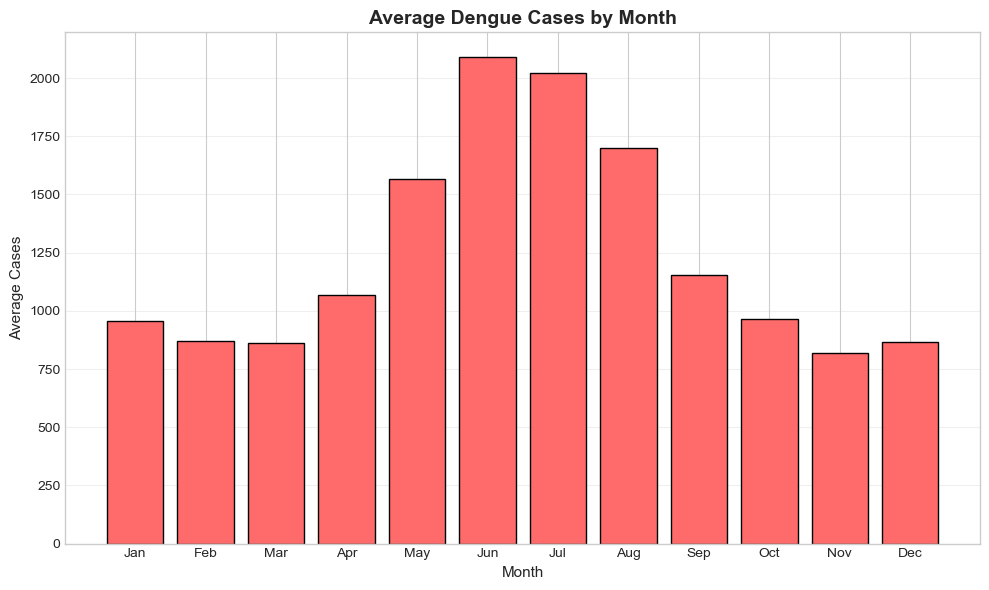


🔴 Peak Month: Jun
🟢 Lowest Month: Nov

✅ Saved: images/03_seasonal.png


In [9]:
# Simple monthly pattern
monthly_avg = df.groupby('month_num')['cases'].mean()

plt.figure(figsize=(10, 6))
plt.bar(range(1, 13), monthly_avg.values, color='#FF6B6B', edgecolor='black')
plt.title('Average Dengue Cases by Month', fontsize=14, fontweight='bold')
plt.xlabel('Month', fontsize=11)
plt.ylabel('Average Cases', fontsize=11)
plt.xticks(range(1, 13), ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 
                           'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'])
plt.grid(alpha=0.3, axis='y')
plt.tight_layout()
plt.savefig('../images/03_seasonal.png', dpi=300, bbox_inches='tight')
plt.show()

# Key insight
peak_month = monthly_avg.idxmax()
months = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']
print(f"\n🔴 Peak Month: {months[peak_month-1]}")
print(f"🟢 Lowest Month: {months[monthly_avg.idxmin()-1]}")
print("\n✅ Saved: images/03_seasonal.png")

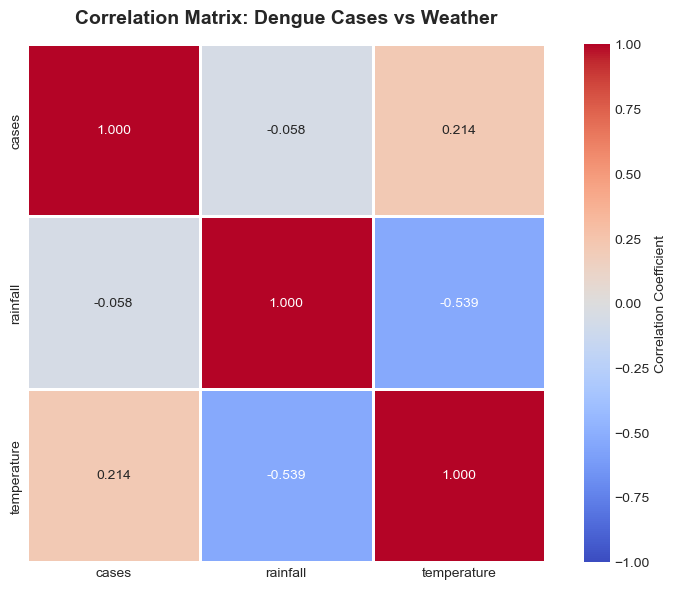


✅ Saved: images/correlation_heatmap.png


In [12]:
# Calculate correlation matrix
corr_matrix = df[['cases', 'rainfall', 'temperature']].corr()

# Create correlation heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, 
            annot=True,           # Show numbers
            fmt='.3f',            # 3 decimal places
            cmap='coolwarm',      # Color scheme (red=positive, blue=negative)
            center=0,             # Center colormap at 0
            square=True,          # Square cells
            linewidths=2,         # White lines between cells
            cbar_kws={'label': 'Correlation Coefficient'},
            vmin=-1, vmax=1)      # Scale from -1 to 1

plt.title('Correlation Matrix: Dengue Cases vs Weather', 
          fontsize=14, fontweight='bold', pad=15)
plt.tight_layout()

# Save
import os
os.makedirs('../images', exist_ok=True)
plt.savefig('../images/correlation_heatmap.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n✅ Saved: images/correlation_heatmap.png")

In [15]:
print("="*60)
print("KEY INSIGHTS")
print("="*60)

# Seasonal
peak = df.groupby('month_num')['cases'].mean().idxmax()
low = df.groupby('month_num')['cases'].mean().idxmin()
months = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']

print(f"\n1. SEASONALITY:")
print(f"   Peak: {months[peak-1]}")
print(f"   Low: {months[low-1]}")

# Overall stats
print(f"\n2. STATISTICS:")
print(f"   Average cases/month: {df['cases'].mean():.1f}")
print(f"   Range: {df['cases'].min():.0f} - {df['cases'].max():.0f}")

KEY INSIGHTS

1. SEASONALITY:
   Peak: Jun
   Low: Nov

2. STATISTICS:
   Average cases/month: 1244.6
   Range: 136 - 6566


# Day 3: Exploratory Data Analysis - Complete ✅

## Visualizations Created:

1. **Correlation Heatmap** - Shows relationships between variables
2. **Time Series (3-panel)** - Cases, rainfall, temperature over 2012-2023
3. **Scatter Plots** - Rainfall vs cases, Temperature vs cases
4. **Seasonal Pattern** - Average cases by month

---

##  Key Findings:

### 1. Correlations:
- **Rainfall ↔ Cases:** -0.058 (Very weak negative)
- **Temperature ↔ Cases:** +0.214 (Weak positive)
- **Rainfall ↔ Temperature:** -0.539 (Moderate negative)

**Insight:** Direct weather correlation is weak, suggesting time-lag effects are important.

---

### 2. Major Outbreaks Identified:
- **2013-2014:** ~3,000-3,500 cases/month
- **2020:** Peak at ~6,500 cases/month (largest outbreak)
- **2022:** Second peak at ~6,500 cases/month
- **2017-2019:** Quiet period (~200-500 cases/month)

**Pattern:** Multi-year outbreak cycles observed.

---

### 3. Strong Seasonality:
- **Peak Months:** June (~ 2,100 cases), July (~ 2,000 cases)
- **High Season:** May-August (>1,500 cases avg)
- **Lowest Month:** November (~830 cases)
- **Low Season:** October-March (<1,000 cases avg)

**Insight:** 2.5x difference between peak and low seasons - month_num will be critical feature.

---

### 4. Weather Patterns:
- **Temperature:** Very stable (24-27°C), narrow range due to equatorial climate
- **Rainfall:** Seasonal variation (50-400mm typical, one spike at 700mm)
- **Surprise:** Heavy rainfall (>400mm) shows lower dengue cases (possibly washes away breeding sites)
